In [110]:
# %conda install seaborn
# %conda install matplotlib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [111]:
df = pd.read_csv("./data/soccer-players.csv")
df.head()

,player_id,first_name,last_name,name,last_season,current_club_id,player_code,country_of_birth,city_of_birth,country_of_citizenship,...,foot,height_in_cm,contract_expiration_date,agent_name,image_url,url,current_club_domestic_competition_id,current_club_name,market_value_in_eur,highest_market_value_in_eur
0,10,Miroslav,Klose,Miroslav Klose,2015,398,miroslav-klose,Poland,Opole,Germany,...,right,184.0,NaN,ASBW Sport Marketing,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/miroslav-klose...,IT1,Società Sportiva Lazio S.p.A.,1000000.0,30000000.0
1,26,Roman,Weidenfeller,Roman Weidenfeller,2017,16,roman-weidenfeller,Germany,Diez,Germany,...,left,190.0,NaN,Neubauer 13 GmbH,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/roman-weidenfe...,L1,Borussia Dortmund,750000.0,8000000.0
2,65,Dimitar,Berbatov,Dimitar Berbatov,2015,1091,dimitar-berbatov,Bulgaria,Blagoevgrad,Bulgaria,...,NaN,NaN,NaN,CSKA-AS-23 Ltd.,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/dimitar-berbat...,GR1,Panthessalonikios Athlitikos Omilos Konstantin...,1000000.0,34500000.0
3,77,NaN,Lúcio,Lúcio,2012,506,lucio,Brazil,Brasília,Brazil,...,NaN,NaN,NaN,NaN,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/lucio/profil/s...,IT1,Juventus Football Club,200000.0,24500000.0
4,80,Tom,Starke,Tom Starke,2017,27,tom-starke,East Germany (GDR),Freital,Germany,...,right,194.0,NaN,IFM,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/tom-starke/pro...,L1,FC Bayern München,100000.0,3000000.0


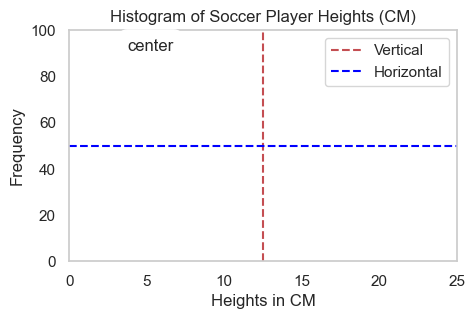

In [112]:
# Annatomy of a Viz
plt.figure(figsize=(5,3))
plt.xlabel("Heights in CM")
plt.ylabel("Frequency")
xmax = 25
plt.xlim(0, xmax)
ymax = 100
plt.ylim(0, ymax)
plt.title("Histogram of Soccer Player Heights (CM)")
string = "center"
# plt.text(x=12.5,y=50,s=string,ha="left",va="bottom")
plt.text(
    x=0.15,
    y=0.9,
    s=string,
    ha="left",
    va="bottom",
    bbox={"boxstyle":"round, pad=0.5", "fc":"white"},
    transform=plt.gca().transAxes)
plt.axvline(x=xmax/2,color="r",linestyle="--",label="Vertical")
plt.axhline(y=ymax/2,color="blue",linestyle="--",label="Horizontal")
plt.grid()
plt.legend()
plt.show()

In [113]:
import scipy.stats as stats

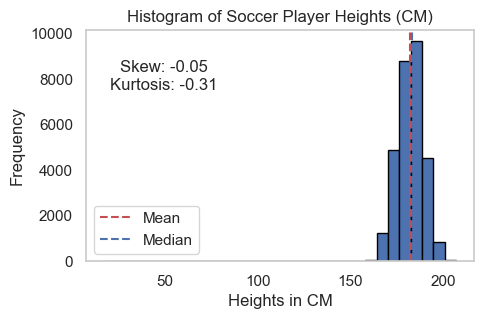

In [114]:

# Histogram with plt
data = df["height_in_cm"].dropna()

plt.figure(figsize=(5,3))
bins = round(data.count() ** (1/3))
plt.hist(x=data,bins=bins,edgecolor="black")
plt.xlabel("Heights in CM")
plt.ylabel("Frequency")
xmax = 25
ymax = 100
plt.title("Histogram of Soccer Player Heights (CM)")
data = data.loc[data>150]
sk = stats.skew(data)
kurt = stats.kurtosis(data)
string = f"""Skew: {sk:.2f}
Kurtosis: {kurt:.2f}"""
# plt.text(x=12.5,y=50,s=string,ha="left",va="bottom")
plt.text(
    x=0.2,
    y=0.8,
    s=string,
    ha="center",
    va="center",
    bbox={"boxstyle":"round, pad=0.5", "fc":"white"},
    transform=plt.gca().transAxes)
plt.axvline(x=data.mean(),color="r",linestyle="--",label="Mean")
plt.axvline(x=data.median(),color="b",linestyle="--",label="Median")
plt.grid()
plt.legend()
plt.show()

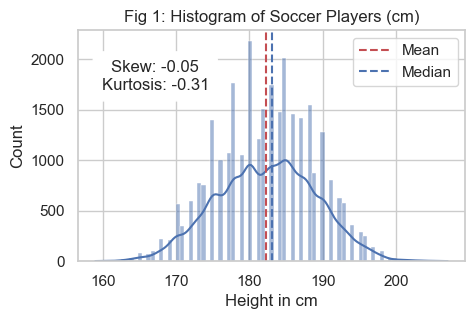

In [120]:

# histogram with sns
df = df.dropna(subset="height_in_cm")
df = df.loc[df["height_in_cm"]>150]
plt.figure(figsize=(5,3))
sns.set_theme(style="whitegrid")
hst = sns.histplot(data=df,x="height_in_cm",kde=True)
hst.set(xlabel="Height in cm")
plt.title("Fig 1: Histogram of Soccer Players (cm)")
plt.text(
    x=0.2,
    y=0.8,
    s=string,
    ha="center",
    va="center",
    bbox={"boxstyle":"round, pad=0.5", "fc":"white"},
    transform=plt.gca().transAxes)
plt.axvline(x=data.mean(),color="r",linestyle="--",label="Mean")
plt.axvline(x=data.median(),color="b",linestyle="--",label="Median")
plt.grid(True)
plt.legend()
plt.show()

As Fig 1 demonstrates, the skewness is -0.05 and the kurtosis is -0.31. This demonstrates...

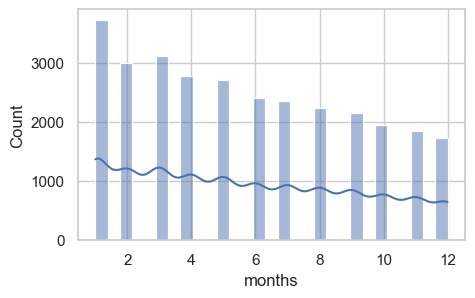

In [121]:
plt.figure(figsize=(5,3))
df["months"] = pd.to_datetime(df["date_of_birth"]).dt.month
hst_months = sns.histplot(data=df,x="months",kde=True)